In [73]:
# Data manipulation and analysis
import pandas as pd                    
import numpy as np
# Machine Learning
from sklearn.model_selection import train_test_split 
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    recall_score,
    precision_score
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier  
from imblearn.over_sampling import SMOTE

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model saving and loading
import joblib

### Step 1: Load and Use the Saved Model

**Demonstration of production-ready model loading**

In [74]:
# Load the model
print("\nLoading model from pickle file...")
loaded_model = joblib.load('backorder_prediction_model.pkl')
loaded_preprocessing = joblib.load('backorder_preprocessing.pkl')

print("\nModel information:")
print(f"  Number of trees: {loaded_model.n_estimators}")
print(f"  Features used: {loaded_model.n_features_in_}")

print("\nStored preprocessing components:")
for key in loaded_preprocessing.keys():
    print(f"  ✓ {key}")


Loading model from pickle file...

Model information:
  Number of trees: 200
  Features used: 33

Stored preprocessing components:
  ✓ scaler
  ✓ label_encoders
  ✓ le_target
  ✓ feature_names


In [75]:
df=pd.read_csv("data/Kaggle_Test_Dataset_v2.csv")
df

C:\Users\pc\AppData\Local\Temp\ipykernel_13072\1205534006.py:1: DtypeWarning: Columns (0: sku) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("data/Kaggle_Test_Dataset_v2.csv")


,sku,national_inv,lead_time,in_transit_qty,forecast_3_month,forecast_6_month,forecast_9_month,sales_1_month,sales_3_month,sales_6_month,...,pieces_past_due,perf_6_month_avg,perf_12_month_avg,local_bo_qty,deck_risk,oe_constraint,ppap_risk,stop_auto_buy,rev_stop,went_on_backorder
0,3285085,62.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,Yes,No,No,Yes,No,No
1,3285131,9.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,-99.00,-99.00,0.0,No,No,Yes,No,No,No
2,3285358,17.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.92,0.95,0.0,No,No,No,Yes,No,No
3,3285517,9.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.78,0.75,0.0,No,No,Yes,Yes,No,No
4,3285608,2.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.54,0.71,0.0,No,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242071,3526988,13.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.48,0.48,0.0,Yes,No,No,Yes,No,No
242072,3526989,13.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.48,0.48,0.0,Yes,No,No,Yes,No,No
242073,3526990,10.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.48,0.48,0.0,Yes,No,No,Yes,No,No
242074,3526991,2913.0,12.0,0.0,0.0,0.0,0.0,0.0,30.0,88.0,...,0.0,0.48,0.48,0.0,Yes,No,No,Yes,No,No


## EDA / Exploratory Functions 

In [ ]:
def descriptive_stats(df, col):
    print(f"Mean {col} : {df[col].mean():.2f}")
    print(f"Median {col}: {df[col].median():.2f}")
    print(f"Minimum {col}: {df[col].min()}")
    print(f"Maximum {col}: {df[col].max()}")
    print(f"Standard Deviation : {df[col].std()}")
    print(f"Range : {df[col].max() - df[col].min()}")
    
    print(f"percentiles :")
    for p in [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
        print(f"{p:.2f} {df[col].quantile(p)}")
    
    print("=" * 60)
    print(f"Skewness: {df[col].skew()}")
    print(f"Kurtosis: {df[col].kurt()}")


def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers count: {len(outliers)}")
    return outliers



def distribution_plots(df, col):
    plt.figure(figsize=(15, 12))
    
    # Plot 1: Histogram + KDE
    plt.subplot(3, 1, 1)
    sns.histplot(df[col], bins=50, kde=True, color='steelblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    # Plot 2: Boxplot
    plt.subplot(3, 1, 2)
    sns.boxplot(x=df[col], color='orange')
    plt.title(f"Boxplot of {col}")
    
    # Plot 3: Violin Plot
    plt.subplot(3, 1, 3)
    sns.violinplot(x=df[col], color='green')
    plt.title(f"Violin Plot of {col}")
    
    plt.tight_layout()
    plt.show()


def check_missing_values(df):
    print("Standard Missing Values:")
    print(df.isnull().sum())
    print("\n" + "=" * 60)
    print("Missing values represented as -99:")
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        count_minus_99 = (df[col] == -99).sum()
        if count_minus_99 > 0:
            print(f"{col}: {count_minus_99} values = -99 ({count_minus_99/len(df)*100:.2f}%)")
    
    print("\nNote: -99 often represents missing or unavailable data")


def class_distribution(df, target_col='went_on_backorder'):
    print(f"Class Distribution of '{target_col}':")
    print(df[target_col].value_counts())
    print(f"\nPercentage:")
    print(df[target_col].value_counts(normalize=True) * 100)
    
    plt.figure(figsize=(10, 5))
    
    # Count plot
    plt.subplot(1, 2, 1)
    sns.countplot(x=df[target_col], palette='Set2')
    plt.title(f"Distribution of {target_col}")
    
    # Pie chart
    plt.subplot(1, 2, 2)
    df[target_col].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightgreen', 'salmon'])
    plt.title(f"Proportion of {target_col}")
    
    plt.tight_layout()
    plt.show()


def comparison_plots(df, cols, title_prefix=""):
    # 1. Histograms side by side
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(cols, 1):
        plt.subplot(1, len(cols), i)
        sns.histplot(df[col], bins=50, kde=True)
        plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()
    
    # 2. Boxplots together
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df[cols])
    plt.title(f"Boxplot Comparison {title_prefix}")
    plt.ylabel("Values")
    plt.show()
    
    # 3. Log-scale histograms
    plt.figure(figsize=(15, 5))
    for i, col in enumerate(cols, 1):
        plt.subplot(1, len(cols), i)
        sns.histplot(df[col], bins=50, kde=True, log_scale=True)
        plt.title(f"Log-Scale Distribution of {col}")
    plt.tight_layout()
    plt.show()


def correlation_with_target(df, col, target_col='went_on_backorder'):
    corr = df[[col, target_col]].corr()
    print("Correlation matrix:")
    print(corr)
    print(f"\nCorrelation of {col} with {target_col}: {corr.iloc[0,1]:.4f}")




def zero_analysis(df, col):
    """
    Analyze how many products have zero or near-zero values.
    Important for inventory and sales columns.
    """
    zero_count = df[df[col] == 0].shape[0]
    near_zero_5 = df[df[col] < 5].shape[0]
    near_zero_10 = df[df[col] < 10].shape[0]
    
    print(f"Products with zero {col}: {zero_count} ({zero_count/len(df)*100:.2f}%)")
    print(f"Products with near-zero {col} (<5): {near_zero_5} ({near_zero_5/len(df)*100:.2f}%)")
    print(f"Products with near-zero {col} (<10): {near_zero_10} ({near_zero_10/len(df)*100:.2f}%)")



# FUNCTION 9: HIGH VALUE / TOP N ANALYSIS
def top_n_analysis(df, col, n=10, quantile_threshold=0.99):
    """
    Identify top N products with highest values in a column.
    """
    threshold = df[col].quantile(quantile_threshold)
    high_value = df[df[col] >= threshold]
    
    print(f"Top {(1-quantile_threshold)*100:.0f}% Threshold: {threshold:.2f}")
    print(f"Products with Very High {col}: {len(high_value):,}")
    print(f"\nTop {n} Products with Highest {col}")
    print(high_value[['sku', col]].sort_values(col, ascending=False).head(n))



# FUNCTION 10: BACKORDER ANALYSIS BY FEATURE
def backorder_analysis(df, col, target_col='went_on_backorder'):
    """
    Analyze how a feature differs between backorder and non-backorder products.
    """
    plt.figure(figsize=(12, 5))
    
    # Grouped statistics
    print(f"\n{'='*60}")
    print(f"Analysis of '{col}' by '{target_col}':")
    print("=" * 60)
    print(df.groupby(target_col)[col].describe())
    
    # Histogram by target
    plt.subplot(1, 2, 2)
    for label in df[target_col].unique():
        subset = df[df[target_col] == label]
        sns.histplot(subset[col], bins=50, kde=True, label=f"{target_col}={label}")
    plt.title(f"Distribution of {col} by {target_col}")
    plt.legend()
    
    plt.tight_layout()
    plt.show()


# FUNCTION 11: DATASET OVERVIEW
def dataset_overview(df):
    """
    Complete overview of the dataset.
    """
    print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\n{'='*60}")
    print("Dataset Info:")
    print(df.info())
    print(f"\n{'='*60}")
    print("First 5 rows:")
    print(df.head())
    print(f"\n{'='*60}")
    print("Duplicates:")
    print(f"Number of duplicate rows: {df.duplicated().sum()}")


# FUNCTION 12: FEATURE SUMMARY TABLE
def feature_summary(df, target_col='went_on_backorder'):
    """
    Generate a summary table for all features.
    """
    summary = pd.DataFrame({
        'Column': df.columns,
        'Type': df.dtypes,
        'Missing': df.isnull().sum(),
        'Missing_%': (df.isnull().sum() / len(df) * 100).round(2),
        'Unique': df.nunique(),
    })
    
    # Add mean/std for numeric columns
    for col in df.select_dtypes(include=[np.number]).columns:
        summary.loc[summary['Column'] == col, 'Mean'] = df[col].mean()
        summary.loc[summary['Column'] == col, 'Std'] = df[col].std()
    
    print(summary.to_string(index=False))
    return summary

In [77]:
def exploratory_analysis(df):
    """
    Perform a comprehensive exploratory analysis on the dataset.
    """
    print("\n=== Dataset Overview ===")
    dataset_overview(df)
    
    print("\n=== Feature Summary ===")
    feature_summary(df)
    
    print("\n=== Missing Values Check ===")
    check_missing_values(df)
    
    print("\n=== Class Distribution ===")
    class_distribution(df)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        print(f"\n=== Descriptive Stats for {col} ===")
        descriptive_stats(df, col)
        
        print(f"\n=== Outlier Detection for {col} ===")
        detect_outliers(df, col)
    
        print(f"\n=== Distribution Plots for {col} ===")
        distribution_plots(df, col)

        # Backorder analysis
        backorder_analysis(df, col=col)
    
    # Compare multiple columns
    sales_cols = ['sales_1_month', 'sales_3_month', 'sales_6_month', 'sales_9_month']
    comparison_plots(df, sales_cols, title_prefix="of Sales Columns")

    forecast_cols = ['forecast_3_month', 'forecast_6_month', 'forecast_9_month']
    comparison_plots(df, forecast_cols, title_prefix="of Forecast Columns")

    # Top N analysis
    top_n_analysis(df, 'national_inv', n=10)
    

In [ ]:
def preprocess_data(df):
    """
    Apply the same preprocessing as in the training pipeline:
    - Drop unnecessary columns
    - Fill missing values (numeric with median, categorical with mode)
    - Handle -99 values
    """
    df = df.copy()
    
    # Drop columns that were dropped during training
    drop_cols = ["deck_risk", "ppap_risk", "stop_auto_buy", "rev_stop"]
    existing_drop_cols = [col for col in drop_cols if col in df.columns]
    df.drop(columns=existing_drop_cols, inplace=True)
    
    # Fill numeric columns with median
    for col in df.select_dtypes(include=[np.number]).columns:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            if pd.isna(median_val):
                df[col] = df[col].fillna(0)
            else:
                df[col] = df[col].fillna(median_val)
    
    # Fill categorical columns with mode
    for col in df.select_dtypes(include=["object"]).columns:
        if df[col].isnull().sum() > 0:
            if not df[col].mode().empty:
                mode_val = df[col].mode()[0]
                df[col] = df[col].fillna(mode_val)
            else:
                df[col] = df[col].fillna("Unknown")
    
    # Remove duplicates
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    print(f"Preprocessing done. Shape: {df.shape}")
    return df


# STEP 1: FEATURE ENGINEERING 
def apply_feature_engineering(df):
    """
    Apply all engineered features exactly as in the training pipeline.
    """
    df = df.copy()
    
    # Feature 1: Total Available Supply
    df['available_supply'] = df['national_inv'] + df['in_transit_qty']
    
    # Feature 2: Supply Gap
    df['supply_gap_3m'] = df['available_supply'] - df['forecast_3_month']
    
    # Feature 3: Supply/Demand Ratio
    df['supply_demand_ratio_3m'] = df['available_supply'] / (df['forecast_3_month'] + 1)
    
    # Feature 4: Inventory vs Minimum Bank
    df['inventory_min_gap'] = df['national_inv'] - df['min_bank']
    df['below_min_bank'] = (df['national_inv'] < df['min_bank']).astype(int)
    
    # Feature 5: Forecast Growth / Long-Term Demand
    df['forcast_growth_3_to_6'] = df['forecast_6_month'] - df['forecast_3_month']
    df['forcast_growth_6_to_9'] = df['forecast_9_month'] - df['forecast_6_month']
    
    df['forecast_monthly_3m'] = df['forecast_3_month'] / 3
    df['forecast_monthly_6m'] = df['forecast_6_month'] / 6
    df['forecast_monthly_9m'] = df['forecast_9_month'] / 9
    
    # Feature 6: Historical Sales Velocity
    df['sales_monthly_3m'] = df['sales_3_month'] / 3
    df['sales_monthly_6m'] = df['sales_6_month'] / 6
    df['sales_monthly_9m'] = df['sales_9_month'] / 9
    
    # Feature 7: Forecast vs Sales
    df['forcast_vs_sales'] = df['forecast_monthly_3m'] / (df['sales_monthly_3m'] + 1)
    
    # Feature 10: Inventory Coverage
    df['inventory_coverage_months'] = df['national_inv'] / (df['forecast_monthly_3m'] + 1)
    
    # Feature 11: Inventory Coverage Including Incoming Stock
    df['total_supply_coverage_months'] = df['available_supply'] / (df['forecast_monthly_3m'] + 1)
    
    print(f"Feature engineering done. Shape: {df.shape}")
    return df

# STEP 2: ENCODE CATEGORICAL VARIABLES (from train.ipynb)
def encode_categoricals(df):
    """
    Encode categorical columns (Yes/No → 1/0) as done in training.
    """
    df = df.copy()
    
    # Binary encoding for Yes/No columns
    binary_cols = ['potential_issue', 'oe_constraint']
    for col in binary_cols:
        if col in df.columns:
            df[col] = df[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)
    
    # Encode target if present (for evaluation only)
    if 'went_on_backorder' in df.columns:
        df['went_on_backorder'] = df['went_on_backorder'].map({'Yes': 1, 'No': 0})
    
    print("Categorical encoding done.")
    return df

def prepare_features(df, feature_names):
    """
    Select ONLY the 33 features the model was trained on.
    Removes sku, went_on_backorder, and any extra columns.
    """
    df = df.copy()
    
    # Remove sku and target if present (keep sku separately for report)
    cols_to_remove = ['sku', 'went_on_backorder']
    for col in cols_to_remove:
        if col in df.columns:
            df = df.drop(columns=[col])
    
    # Check missing columns
    missing_cols = [col for col in feature_names if col not in df.columns]
    if missing_cols:
        print(f"  WARNING: Missing columns (filled with 0): {missing_cols}")
        for col in missing_cols:
            df[col] = 0
    
    # Select ONLY training features in the correct order
    X = df[feature_names].copy()
    
    print(f"  Features prepared. Shape: {X.shape}")
    print(f"  Feature count matches model: {X.shape[1] == len(feature_names)}")
    
    return X

def scale_features(X, scaler):
    """
    Scale features using the SAME scaler from training.
    """
    X_scaled = scaler.transform(X)
    X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    print(f"  Features scaled. Shape: {X_scaled.shape}")
    return X_scaled


# STEP 3: PREDICTION AND EVALUATION

def predict_backorder(model, X_scaled, threshold=0.5):
    """
    Predict backorder with configurable threshold.
    """
    y_pred_proba = model.predict_proba(X_scaled)[:, 1]
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    print(f"  Predictions done.")
    print(f"  Threshold: {threshold}")
    print(f"  Positive rate: {y_pred.mean()*100:.2f}%")
    print(f"  Predicted backorders: {y_pred.sum():,}")
    
    return y_pred, y_pred_proba


def evaluate_model(y_true_encoded, y_pred, y_pred_proba, le_target=None):
    print("\n" + "=" * 70)
    print("MODEL EVALUATION ON TEST DATA")
    print("=" * 70)
    
    # Accuracy
    acc = accuracy_score(y_true_encoded, y_pred)
    print(f"\nAccuracy: {acc:.4f}")
    
    # Classification Report
    target_names = list(le_target.classes_) if le_target else ['No', 'Yes']
    print(f"\nClassification Report:")
    print(classification_report(y_true_encoded, y_pred, target_names=target_names))
    
    # Individual metrics
    print(f"Precision : {precision_score(y_true_encoded, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true_encoded, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true_encoded, y_pred):.4f}")
    
    # ROC-AUC
    auc = roc_auc_score(y_true_encoded, y_pred_proba)
    print(f"ROC-AUC   : {auc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_true_encoded, y_pred)
    print(f"\nConfusion Matrix:")
    print(cm)
    
    return {
        'accuracy': acc,
        'precision': precision_score(y_true_encoded, y_pred),
        'recall': recall_score(y_true_encoded, y_pred),
        'f1': f1_score(y_true_encoded, y_pred),
        'roc_auc': auc,
        'confusion_matrix': cm
    }

# STEP 4: THRESHOLD ANALYSIS

def find_optimal_threshold(y_true_encoded, y_pred_proba, target_positive_rate=None):
    """
    Find the best threshold that balances precision and recall.
    Optionally match a target positive rate.
    """
    precisions, recalls, thresholds = precision_recall_curve(y_true_encoded, y_pred_proba)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    
    # Best F1 threshold
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    
    print(f"Best threshold by F1: {best_threshold:.4f}")
    print(f"  Precision at best: {precisions[best_idx]:.4f}")
    print(f"  Recall at best:    {recalls[best_idx]:.4f}")
    print(f"  F1 at best:        {f1_scores[best_idx]:.4f}")
    
    # If target positive rate specified
    if target_positive_rate is not None:
        target_count = int(len(y_pred_proba) * target_positive_rate)
        sorted_indices = np.argsort(y_pred_proba)[::-1]
        threshold_at_target = y_pred_proba[sorted_indices[target_count]]
        print(f"\nThreshold for {target_positive_rate*100:.2f}% positive rate: {threshold_at_target:.4f}")
    
    # Plot
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(thresholds, precisions[:-1], 'b-', label='Precision')
    plt.plot(thresholds, recalls[:-1], 'r-', label='Recall')
    plt.plot(thresholds, f1_scores[:-1], 'g-', label='F1-Score')
    plt.axvline(best_threshold, color='orange', linestyle='--', label=f'Best F1 = {best_threshold:.3f}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Threshold vs Metrics')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(recalls[:-1], precisions[:-1], 'b-')
    plt.axhline(precisions[best_idx], color='orange', linestyle='--')
    plt.axvline(recalls[best_idx], color='orange', linestyle='--')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    
    plt.tight_layout()
    plt.show()
    
    return best_threshold

# STEP 5: Risk Analysis and Reporting
def generate_risk_based_report(df, y_pred, y_pred_proba, top_n=20):
    """
    Don't use binary Yes/No. Use probability tiers for action.
    """
    results = pd.DataFrame()
    
    if 'sku' in df.columns:
        results['sku'] = df['sku'].values

    results['prediction']=y_pred
    results['backorder_probability'] = y_pred_proba
    
    # Risk tiers based on probability
    results['risk_level'] = pd.cut(
        y_pred_proba,
        bins=[0, 0.1, 0.3, 0.5, 0.7, 0.85, 1.0],
        labels=['Very Low', 'Low', 'Medium', 'High', 'Very High', 'Critical']
    )
    
    results['action'] = results['risk_level'].map({
        'Very Low':  'No action needed',
        'Low':       'Standard monitoring',
        'Medium':    'Review inventory levels',
        'High':      'Contact supplier, check lead times',
        'Very High': 'Expedite replenishment order',
        'Critical':  'IMMEDIATE action - risk of stockout'
    })
    
    results = results.sort_values('backorder_probability', ascending=False)
    
    print(f"\n{'='*70}")
    print(f"RISK-BASED BACKORDER REPORT")
    print(f"{'='*70}")
    print(f"\nRisk Distribution:")
    print(results['risk_level'].value_counts().sort_index().to_string())
    print(f"\nTop {top_n} Highest Risk Products:")
    print(results.head(top_n).to_string(index=False))
    
    return results



In [83]:
def predict_new_data(df,feature_names, loaded_model, scaler,threshold=None):
    """
    Predict backorder status for new data using the loaded model and preprocessing.
    """
    # Preprocess the data
    print("[1/6] Preprocessing...")
    df_processed = preprocess_data(df)
    print("\n[2/6] Applying feature engineering...")
    df_processed = apply_feature_engineering(df_processed)
    print("\n[3/6] Encoding categoricals...")
    df_processed = encode_categoricals(df_processed)
    y_true= df_processed['went_on_backorder'].values if 'went_on_backorder' in df_processed.columns else None
    print("\n[4/6] Preparing features...")
    df_processed = prepare_features(df_processed, feature_names)
    print("\n[5/6] Scaling features...")

    X_scaled = scale_features(df_processed, scaler)
    
    print("\n[6/6] Predicting backorders...")
    
    # STEP A: Get raw probabilities from the model
    y_pred_proba = loaded_model.predict_proba(X_scaled)[:, 1]
    
    # STEP B: Find optimal threshold (only if we have true labels and no manual threshold is provided)
    if threshold is None and y_true is not None:
        best_threshold = find_optimal_threshold(y_true, y_pred_proba)
    elif threshold is None:
        best_threshold = 0.83  # Use your previously found best threshold as fallback
    else:
        best_threshold = threshold
        
    # STEP C: Apply threshold to get binary predictions (0 or 1)
    y_pred = (y_pred_proba >= best_threshold).astype(int)
    
    # Evaluate if target exists
    metrics = None
    if y_true is not None:
        metrics = evaluate_model(y_true, y_pred, y_pred_proba)
    
    # Generate risk report
    risk_report = generate_risk_based_report(df, y_pred, y_pred_proba, top_n=20)
    
    print("\n" + "="*70)
    print("PIPELINE COMPLETE!")
    print("="*70)
    
    return y_true, y_pred, y_pred_proba, metrics, risk_report

[1/6] Preprocessing...


C:\Users\pc\AppData\Local\Temp\ipykernel_13072\2002637590.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=["object"]).columns:


Preprocessing done. Shape: (242076, 19)

[2/6] Applying feature engineering...
Feature engineering done. Shape: (242076, 35)

[3/6] Encoding categoricals...
Categorical encoding done.

[4/6] Preparing features...
  Features prepared. Shape: (242076, 33)
  Feature count matches model: True

[5/6] Scaling features...
  Features scaled. Shape: (242076, 33)

[6/6] Predicting backorders...
Best threshold by F1: 0.8303
  Precision at best: 0.2434
  Recall at best:    0.3743
  F1 at best:        0.2950


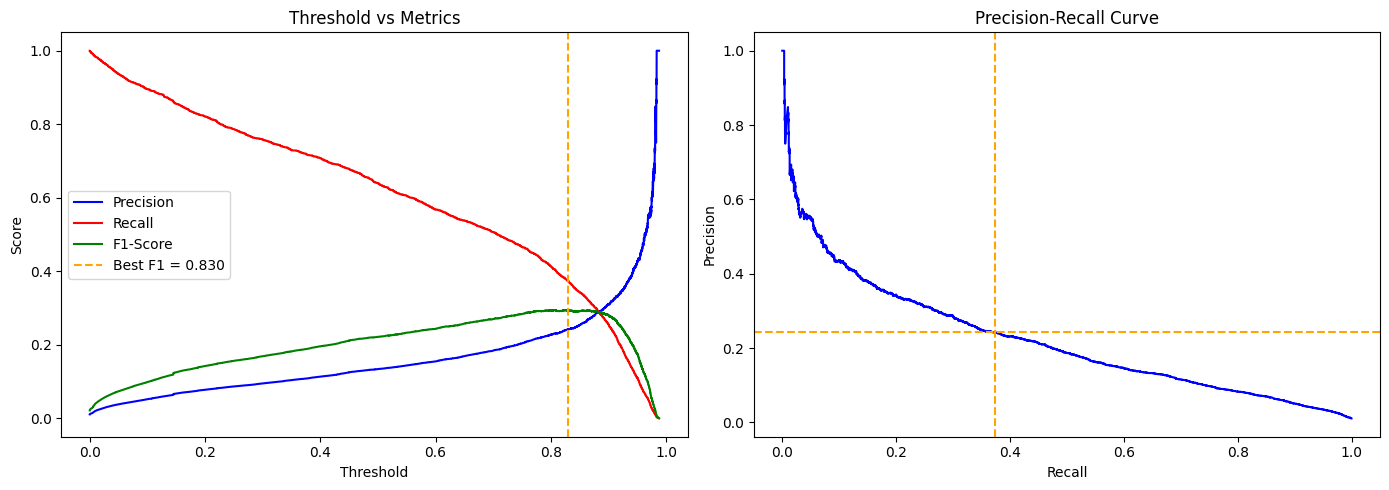


MODEL EVALUATION ON TEST DATA

Accuracy: 0.9801

Classification Report:
              precision    recall  f1-score   support

          No       0.99      0.99      0.99    239388
         Yes       0.24      0.37      0.29      2688

    accuracy                           0.98    242076
   macro avg       0.62      0.68      0.64    242076
weighted avg       0.98      0.98      0.98    242076

Precision : 0.2434
Recall    : 0.3743
F1-Score  : 0.2950
ROC-AUC   : 0.9304

Confusion Matrix:
[[236261   3127]
 [  1682   1006]]

RISK-BASED BACKORDER REPORT

Risk Distribution:
risk_level
Very Low     196110
Low           24567
Medium         8603
High           5418
Very High      3744
Critical       3633

Top 20 Highest Risk Products:
    sku  prediction  backorder_probability risk_level                              action
3487562           1               0.987594   Critical IMMEDIATE action - risk of stockout
3327259           1               0.986718   Critical IMMEDIATE action - risk o

In [84]:
scaler= loaded_preprocessing['scaler']
feature_names=loaded_preprocessing['feature_names']
# 3. Run the prediction pipeline
y_true, y_pred, y_pred_proba, metrics, risk_report = predict_new_data(df, feature_names, loaded_model, scaler)


# Author
### <a href="https://www.linkedin.com/in/salma-belaicha-04a646336/" target="_blank">Salma Belaicha</a>